# Importar Biblioteca

In [74]:
import pandas as pd
import duckdb
import re


# Conectar Duckdb to DataFrame Pandas

In [75]:
# conectar ao banco de dados duckdb
conn = duckdb.connect('./duckdb/instagram.duckdb')

# ler a tabela medias do duckdb
df = conn.execute("SELECT * FROM medias").fetchdf()

# desconectar do banco de dados
conn.close()


# DataFrame com Dados Resumidos

In [76]:
# Visualização das primeiras linhas do dataframe
display(df.head())

,id,caption,media_type,like_count,comments_count,media_url,permalink,timestamp,username
0,18458023078097142,Fala forrozeiros do meu coração ❤️ ❤️ ❤️ \n\n🦎...,VIDEO,23,2,https://instagram.fjdf7-1.fna.fbcdn.net/o1/v/t...,https://www.instagram.com/reel/DWVDHyRDTZB/,2026-03-26 01:17:06,djkalango
1,18057575402463021,Fala forrozeiros do meu coração ❤️ ❤️ ❤️ \n\n🦎...,VIDEO,33,5,https://instagram.fjdf7-1.fna.fbcdn.net/o1/v/t...,https://www.instagram.com/reel/DWVBLV_D0EE/,2026-03-26 01:14:08,djkalango
2,18105873043883968,NaN,VIDEO,136,16,https://instagram.fjdf2-2.fna.fbcdn.net/o1/v/t...,https://www.instagram.com/reel/DV7GmGbjR4s/,2026-03-15 23:27:35,djkalango
3,17849716308635070,Fala forrozeiros do meu coração! ❤️❤️❤️ \n\nVe...,VIDEO,13,3,https://instagram.fjdf7-1.fna.fbcdn.net/o1/v/t...,https://www.instagram.com/reel/DUi40ckDgkW/,2026-02-09 17:15:01,djkalango
4,17863397379580241,Fala forrozeiros do meu coração! ❤️❤️❤️ \n\nNe...,VIDEO,29,2,https://instagram.fjdf7-1.fna.fbcdn.net/o1/v/t...,https://www.instagram.com/reel/DUbRNPJDg0E/,2026-02-06 18:13:09,djkalango


In [77]:
# Exibir as últimas linhas
display(df.tail())

,id,caption,media_type,like_count,comments_count,media_url,permalink,timestamp,username
1251,17975579599884261,"Fala forrozeiros do meu coração, você sabe qua...",VIDEO,80,4,https://instagram.fjdf2-2.fna.fbcdn.net/o1/v/t...,https://www.instagram.com/reel/ClTz-nxsa2a/,2022-11-23 16:09:28,djkalango
1252,18190994848232949,"Faaaala forrozeiros do meu coração, preparados...",IMAGE,77,2,https://scontent.cdninstagram.com/v/t51.82787-...,https://www.instagram.com/p/ClOW651rFbr/,2022-11-21 13:16:42,djkalango
1253,17943442784281113,Faaaala forrozeiros do meu coração. 💃🕺\n\nÉ ju...,VIDEO,32,6,https://instagram.fjdf2-2.fna.fbcdn.net/o1/v/t...,https://www.instagram.com/reel/ClJRDLwOPiQ/,2022-11-19 13:51:01,djkalango
1254,17850840350866474,"Faaaaala forrozeiros do meu coração, hoje o #t...",CAROUSEL_ALBUM,45,2,https://scontent.cdninstagram.com/v/t51.82787-...,https://www.instagram.com/p/ClEB1NBLTcd/,2022-11-17 13:00:01,djkalango
1255,18192478201211982,"Fala forrozeiros do meu coração, você sabe que...",VIDEO,32,6,https://instagram.fjdf7-1.fna.fbcdn.net/o1/v/t...,https://www.instagram.com/reel/ClB-wsxp7XH/,2022-11-16 17:57:05,djkalango


In [78]:
# Exibir uma amostra aleatória
display(df.sample(5))

,id,caption,media_type,like_count,comments_count,media_url,permalink,timestamp,username
245,17906875606308477,"6o.Arraiá beneficente do @ascomcer. \nSábado, ...",VIDEO,24,1,https://instagram.fjdf7-1.fna.fbcdn.net/o1/v/t...,https://www.instagram.com/p/ByY72bRBwxt/,2019-06-07 01:21:35,djkalango
509,17918727799211327,@djkalango passeando em #almenara.,IMAGE,46,0,https://scontent.cdninstagram.com/v/t51.82787-...,https://www.instagram.com/p/Bn4ZE04h-3L/,2018-09-18 20:37:12,djkalango
1006,17863352392001849,Domingo tem #forró #casadapraça #djkalango,IMAGE,6,2,https://scontent.cdninstagram.com/v/t51.82787-...,https://www.instagram.com/p/BJ6cMOTBl9-/,2016-09-04 00:01:05,djkalango
522,17946093172185857,Arraiá do @chopp.botecario sábado e domingo. \...,IMAGE,7,0,https://scontent.cdninstagram.com/v/t51.82787-...,https://www.instagram.com/p/BmvyYkJhkjQ/,2018-08-21 15:53:47,djkalango
281,18063363845407777,Fala Forrozeiros do meu coração ❤️❤️❤️\n\n#TBT...,CAROUSEL_ALBUM,60,10,https://scontent.cdninstagram.com/v/t51.82787-...,https://www.instagram.com/p/DRAoPC2jx4t/,2025-11-13 20:19:58,djkalango


# Descrição e Informações do Data Frame

In [79]:
# Quantidade total de linhas e colunas do dataframe
display(df.shape)

(1256, 9)

In [80]:
# Ver nomes das colunas
display(df.columns)

Index(['id', 'caption', 'media_type', 'like_count', 'comments_count',
       'media_url', 'permalink', 'timestamp', 'username'],
      dtype='str')

In [81]:
# Ver colunas e tipos
display(df.dtypes)

id                         int64
caption                      str
media_type                   str
like_count                 int32
comments_count             int32
media_url                    str
permalink                    str
timestamp         datetime64[us]
username                     str
dtype: object

In [82]:
# Contar valores nulos por coluna
display(df.isnull().sum())

id                  0
caption           138
media_type          0
like_count          0
comments_count      0
media_url           0
permalink           0
timestamp           0
username            0
dtype: int64

In [83]:
# Informações gerais: tipos de dados, memória, valores nulos
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              1256 non-null   int64         
 1   caption         1118 non-null   str           
 2   media_type      1256 non-null   str           
 3   like_count      1256 non-null   int32         
 4   comments_count  1256 non-null   int32         
 5   media_url       1256 non-null   str           
 6   permalink       1256 non-null   str           
 7   timestamp       1256 non-null   datetime64[us]
 8   username        1256 non-null   str           
dtypes: datetime64[us](1), int32(2), int64(1), str(5)
memory usage: 78.6 KB


None

In [84]:
# descicao geral do dataframe
display(df.describe())

,id,like_count,comments_count,timestamp
count,1.256000e+03,1256.000000,1256.000000,1256
mean,1.794143e+16,34.988057,3.057325,2019-07-09 07:05:54.557324
min,1.784155e+16,0.000000,0.000000,2012-10-21 13:57:17
25%,1.786445e+16,15.000000,0.000000,2017-07-24 18:13:24.250000
50%,1.791875e+16,28.000000,1.000000,2018-12-03 05:07:47.500000
75%,1.798967e+16,47.000000,2.000000,2022-05-24 04:12:31.750000
max,1.853927e+16,216.000000,616.000000,2026-03-26 01:17:06
std,1.010888e+14,28.997442,19.112455,NaN


# Consultas SQL convertidas para Dataframa

In [85]:
# Quantidade total de mídias
total_medias = len(df)
display(f"Total de mídias: {total_medias}")


'Total de mídias: 1256'

In [86]:
# Quantidade de mídias por tipo
medias_por_tipo = df.groupby("media_type").size().reset_index(name="count").sort_values("media_type")
display(medias_por_tipo)


,media_type,count
0,CAROUSEL_ALBUM,82
1,IMAGE,855
2,VIDEO,319


In [87]:
# Quantidade total de curtidas
total_likes = df["like_count"].sum()
display(f"Total de curtidas: {total_likes}")


'Total de curtidas: 43945'

In [88]:
# Quantidade total de comentários
total_comments = df["comments_count"].sum()
display(f"Total de comentários: {total_comments}")


'Total de comentários: 3840'

In [89]:
# Postagens com mais comentários (top 5)
top_comentadas = df.sort_values("comments_count", ascending=False).head(5)
display(top_comentadas[["id", "caption", "comments_count"]])


,id,caption,comments_count
292,18088544653934851,SORTEIOS REALIZADO\nganhadora foi @tatianapere...,616
23,18079243063899976,"Sorteio realizado, a sortuda foi @a.patydosca...",202
105,17857373438770240,"Fala forrozeiros do meu coração, na última qui...",78
345,17922777829274176,SORTEIO\n\nDJ Kalango vai sortear 1 ingresso p...,77
302,18013049497169503,"Para concorrer é fácil!!! Marque 2 amigos, cur...",67


In [90]:
# Postagem mais antiga
mais_antiga = df.sort_values("timestamp", ascending=True).head(1)
display(mais_antiga[["id", "caption", "timestamp"]])


,id,caption,timestamp
1155,17842240510056037,Escolhendo o repertório da 2a Forrozada JF. E ...,2012-10-21 13:57:17


In [91]:

# Quantidade de postagens por ano, com o mais curtido e mais comentado
df["ANO"] = pd.to_datetime(df["timestamp"]).dt.year
postagens_por_ano = (
    # agrupamento por ano
    df.groupby("ANO")
      # o agg faz com que seja possível calcular várias estatísticas ao mesmo tempo
      .agg(
          # quantidade de postagens por ano
          QuantidadePost=("id", "count"),
          # post mais/max curtido por ano
          PostMaisCurtido=("like_count", "max"),
          # post mais/max comentado por ano
          PostMaisComentado=("comments_count", "max")
      )
      # resetar o index para transformar o ano em uma coluna normal
      .reset_index()
      # ordenar por ano
      .sort_values("ANO", ascending=False)
)
display(postagens_por_ano)


,ANO,QuantidadePost,PostMaisCurtido,PostMaisComentado
13,2026,12,136,16
12,2025,80,129,616
11,2024,29,126,28
10,2023,79,135,29
9,2022,121,216,78
8,2021,8,205,35
7,2020,32,158,56
6,2019,239,170,77
5,2018,270,135,22
4,2017,194,175,35


# Gerar Gráficos

In [92]:
# importar matplotlib para visualização
import matplotlib.pyplot as plt

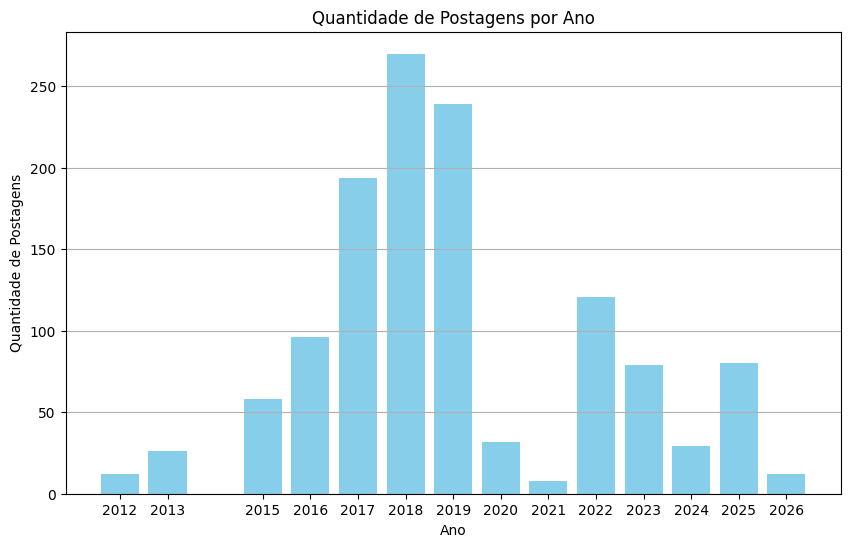

In [93]:
# Gráfico de postagens por ano
plt.figure(figsize=(10, 6))
plt.bar(postagens_por_ano["ANO"], postagens_por_ano["QuantidadePost"], color="skyblue")
plt.title("Quantidade de Postagens por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Postagens")
plt.xticks(postagens_por_ano["ANO"])
plt.grid(axis="y")
plt.show()

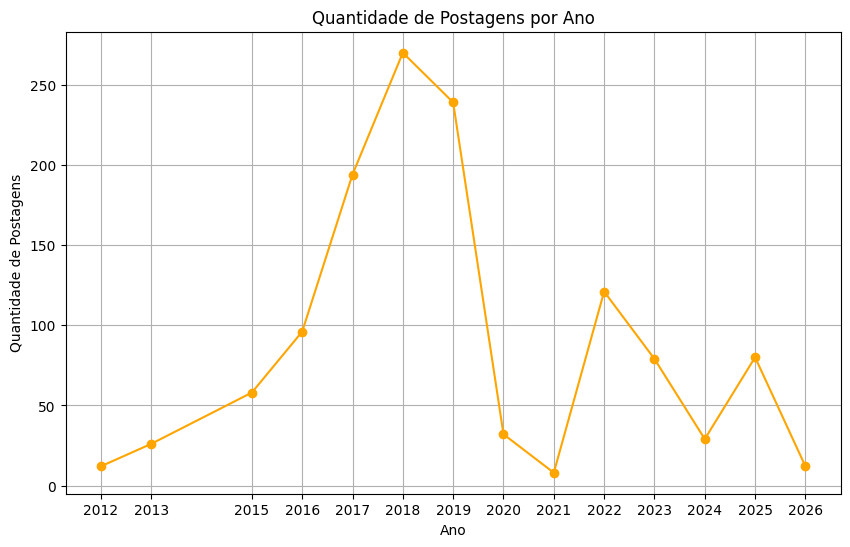

In [94]:
# Gráfico de linha com postagens por ano
plt.figure(figsize=(10, 6))
plt.plot(postagens_por_ano["ANO"], postagens_por_ano["QuantidadePost"], marker="o", color="orange")
plt.title("Quantidade de Postagens por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Postagens")
plt.xticks(postagens_por_ano["ANO"])
plt.grid()
plt.show()

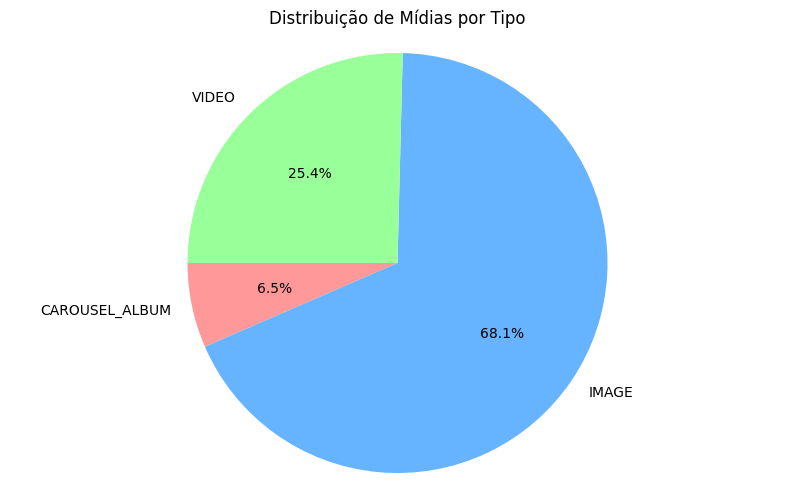

In [95]:
# Gráfico de pizza -Quantidade de mídias por tipo
plt.figure(figsize=(10, 6))
# alteracao das cores do grafico de pizza
colors = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99", "#c2c2f0", "#ffb3e6"]
plt.pie(medias_por_tipo["count"], labels=medias_por_tipo["media_type"], autopct="%1.1f%%", startangle=180, colors=colors)
plt.title("Distribuição de Mídias por Tipo")
plt.axis("equal")
plt.show()

# Abrir imagem pelo link media url

In [96]:
import requests
from PIL import Image
from io import BytesIO

# URL da media
media_url = df['media_url'][0]
media_type = df['media_type'][0]

# URL da imagem
media_url  = df[df['media_type'] == 'IMAGE']['media_url'].iloc[10]
media_type = df[df['media_type'] == 'IMAGE']['media_type'].iloc[10]

if media_type != "IMAGE":
    print("A mídia não é uma imagem. Tipo:", media_type)
else:
    # Faz a requisição HTTP
    response = requests.get(media_url)

    # Verifica se deu certo
    if response.status_code == 200:
        # Converte o conteúdo em objeto de imagem
        img = Image.open(BytesIO(response.content))
        img.show()  # abre no visualizador padrão
    else:
        print("Erro ao baixar imagem:", response.status_code)


Erro ao baixar imagem: 403


# Outras Análises


## 1. Média de likes em post com ou sem sorteios

In [97]:
# Criar uma coluna auxiliar, vou procurar o radical "sort" e colocar 1 caso tenha a palavra na descrição e 0 caso contrário

df['sorteio'] = df['caption'].str.contains('sort', case=False, na=False)

# Agrupando pela coluna 'sorteio'
resumo = df.groupby('sorteio').agg(
    contagem_linhas=('sorteio', 'count'),
    media_likes=('like_count', 'mean')
).reset_index()

print(resumo)

   sorteio  contagem_linhas  media_likes
0    False             1241    34.966156
1     True               15    36.800000


Apenas 15 ocorrências de sorteio, poucas ocorrências para tentar fazer alguma análise além do que já havia sido feita (muitos comentários em posts de sorteio),

## 2. Análise de "Fala"

In [98]:
top_comentadas = df.sort_values("comments_count", ascending=False).head(25)
display(top_comentadas[["id", "caption", "comments_count"]])

,id,caption,comments_count
292,18088544653934851,SORTEIOS REALIZADO\nganhadora foi @tatianapere...,616
23,18079243063899976,"Sorteio realizado, a sortuda foi @a.patydosca...",202
105,17857373438770240,"Fala forrozeiros do meu coração, na última qui...",78
345,17922777829274176,SORTEIO\n\nDJ Kalango vai sortear 1 ingresso p...,77
302,18013049497169503,"Para concorrer é fácil!!! Marque 2 amigos, cur...",67
140,18113145931088644,Fala forrozeiros do meu coração ❤️.\n.\nObriga...,56
58,18049281646357754,Hoje completa cinco anos que eu e a senhora Ka...,53
99,17970329425633622,"Faaaala forrozeiros do meu coração, olha mais ...",48
109,18211139398196134,Faaaaala forrozeiros do meu coração. 💃🕺\n\nEss...,38
775,17889868816064308,#jaera,35


In [99]:
print(df['caption'].loc[300])

#bailabrasil #djkalango #forró #pédeserra #balada #forro #xote #forrójf #forregae #dance #xaxado #vaiforró #forróemjf 
#dançadesalão #festivaldeforró #baião #auladedança #dancadesalao #pedeserra #forrozeiros #danceadois #forrodosamigos #forrozeiro 
#forroroots #brazil #forropesado #cerveja #music #roots


In [100]:
# 1. Usamos regex para extrair a primeira sequência de 'a' entre 'F' e 'L'
# f(a+)l -> Procura um 'f', captura todos os 'a's seguintes, até chegar no 'l'
extracao = df['caption'].str.extract(r'f(a+)l', expand=False, flags=re.IGNORECASE)

# 2. Criamos a coluna contando o tamanho dessa captura.
# Se não encontrar a palavra, preenchemos com 0.
df['contagem_a_fala'] = extracao.str.len().fillna(0).astype(int)

In [101]:

resumo_as = df['contagem_a_fala'].value_counts().sort_index().reset_index()


resumo_as.columns = ['quantidade_de_as', 'total_de_linhas']

print(resumo_as)

   quantidade_de_as  total_de_linhas
0                 0              989
1                 1              167
2                 3               38
3                 4               47
4                 5               12
5                 6                3


In [102]:
# Ok, foram separados quero ver o percentual de postagens que contenham "Fala" e sua variações:

percentual_fala = (df['contagem_a_fala'] > 0).sum() / len(df) * 100

print(f'{percentual_fala:.2f}%')

21.26%


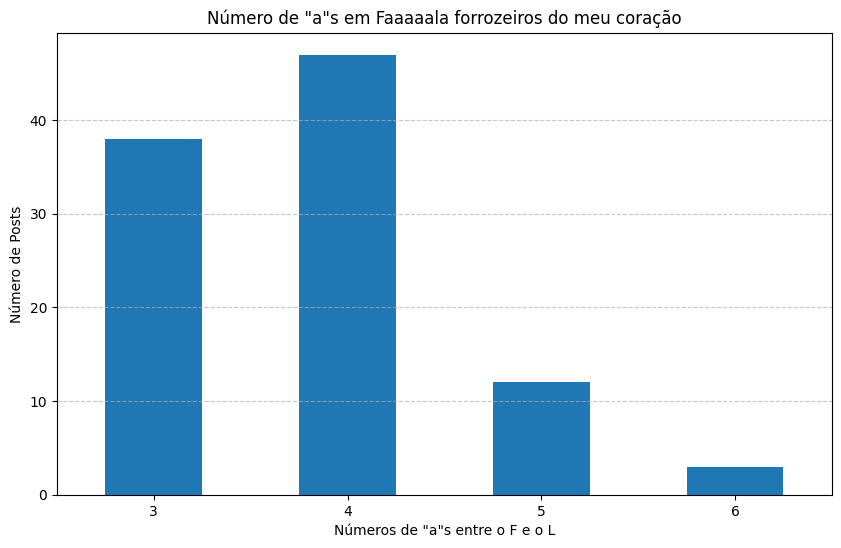

In [103]:
falas = df[df['contagem_a_fala'] > 1]['contagem_a_fala'].value_counts().sort_index()


plt.figure(figsize=(10, 6))
falas.plot(kind='bar')

# 3. Customização para facilitar a leitura
plt.title('Número de "a"s em Faaaaala forrozeiros do meu coração')
plt.xlabel('Números de "a"s entre o F e o L')
plt.ylabel('Número de Posts')
plt.xticks(rotation=0) # Deixa os números do eixo X retos
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


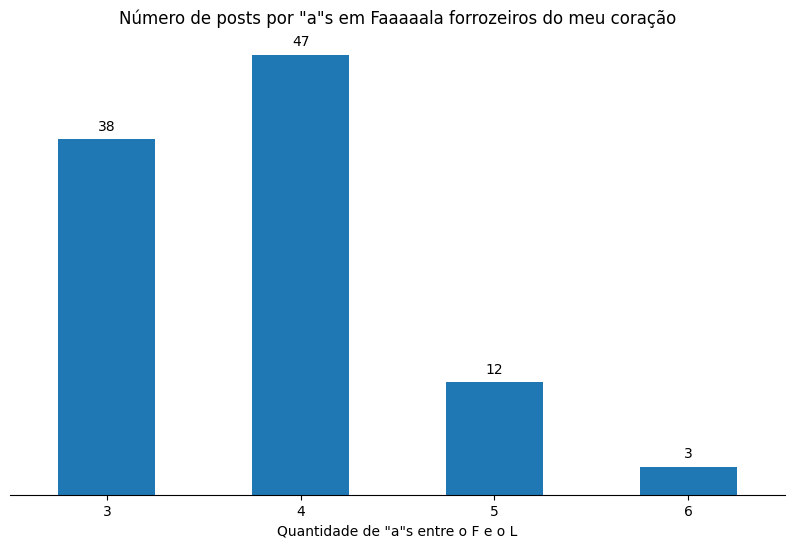

In [104]:
plt.figure(figsize=(10, 6))
ax = falas.plot(kind='bar')

for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

ax.get_yaxis().set_visible(False) # Esconde o eixo Y (números e linha)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)


plt.title('Número de posts por "a"s em Faaaaala forrozeiros do meu coração')
plt.xlabel('Quantidade de "a"s entre o F e o L')
plt.xticks(rotation=0)

plt.show()

Interessante que a variação "Faala" não foi utilizada. "Faaaala" é mais frequente que "Faaala"

## 3. Emojis

In [ ]:
import emoji

# Função para checar se há emoji
def tem_emoji(texto):
    if pd.isna(texto):
        return False
    return emoji.emoji_count(str(texto)) > 0

# Criando a coluna
df['possui_emoji'] = df['caption'].apply(tem_emoji)

In [106]:

percentual_emoji = (df['possui_emoji'] == True).sum() / len(df) * 100

print(f'{percentual_emoji:.2f}%')

24.44%


In [107]:
from collections import Counter

# Extrai todos os emojis de todas as legendas de uma vez só
todos_os_emojis = [
    item['emoji']
    for texto in df['caption'].dropna()
    for item in emoji.emoji_list(str(texto))
]

# Conta as ocorrências usando o Counter (nativo do Python e muito rápido)
contagem = Counter(todos_os_emojis)
print(contagem.most_common(20))

[('❤️', 377), ('🪗', 209), ('💃', 160), ('🕺', 151), ('🦎', 132), ('🎧', 123), ('🥁', 117), ('🔥', 84), ('🍻', 80), ('🗓️', 69), ('⏰', 61), ('🎶', 36), ('🙏', 30), ('🎉', 26), ('📆', 25), ('📸', 24), ('📍', 21), ('🎥', 21), ('♥️', 19), ('📌', 18)]


## 4. Wordcloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\menar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


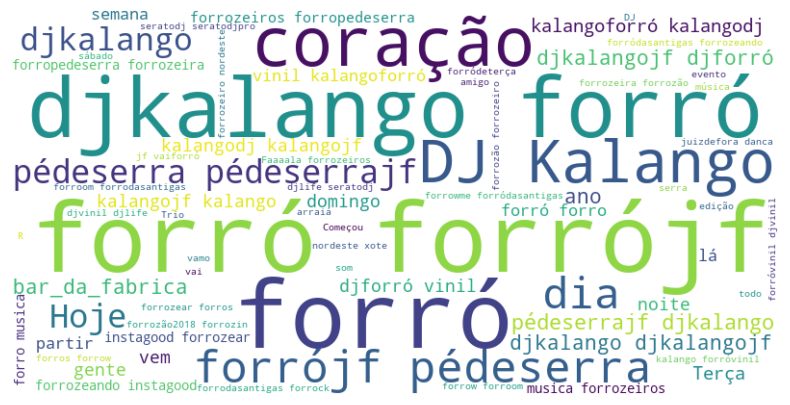

In [111]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords
import string

# Baixar a lista de palavras vazias em português
nltk.download('stopwords')
stop_words_pt = set(stopwords.words('portuguese'))

# 1. Preparar o texto (Exemplo com sua coluna 'caption')
# Vamos juntar todas as linhas em uma única string gigante
texto_completo = " ".join(df['caption'].dropna().astype(str))
# .dropna() AKI


# 2. Limpeza Adicional (Opcional, mas recomendada)
# Adicione palavras específicas do seu contexto que você quer ignorar
stop_words_pt.update(['pra', 'pro', 'então', 'fala', 'aqui', 'tudo'])

# 3. Configurar a WordCloud
nuvem = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stop_words_pt,
    colormap='viridis',      # Cores das palavras
    max_words=100,           # Limite de palavras na tela
    min_font_size=10
).generate(texto_completo)

# 4. Exibir o gráfico
plt.figure(figsize=(10, 5))
plt.imshow(nuvem, interpolation='bilinear')
plt.axis("off") # Remove os eixos (números)
plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\menar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


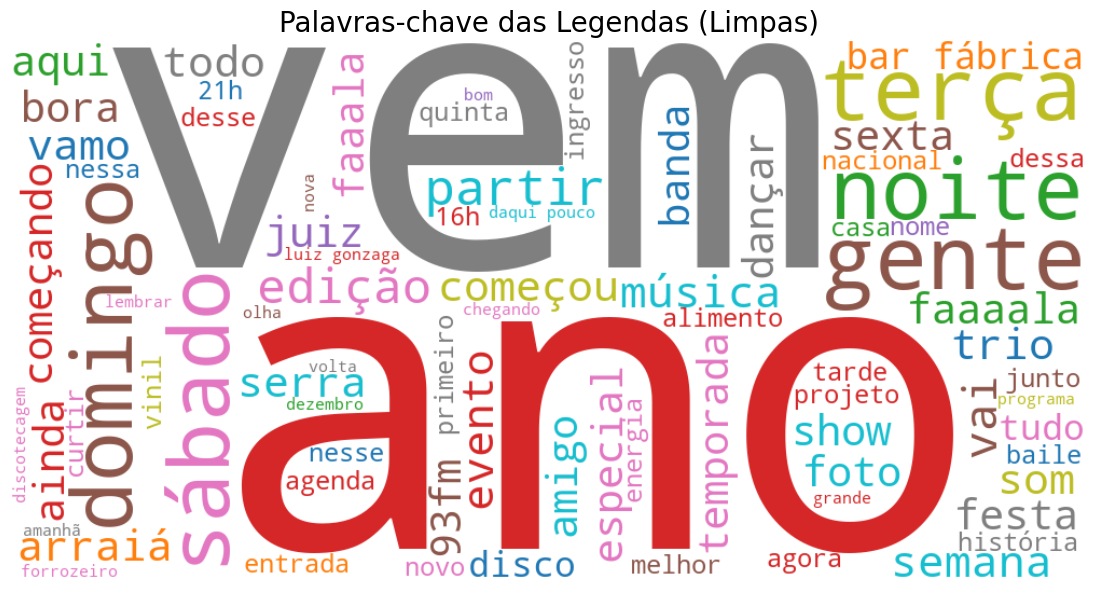

In [109]:
# Não ficou muito informativo

# 1. Garantir que as stopwords estejam prontas
nltk.download('stopwords')
stop_words_pt = set(stopwords.words('portuguese'))

# 2. Adicionar as palavras específicas que você solicitou e variações comuns
termos_remover = ['dj', 'kalango', 'forro', 'forró', 'pra', 'pro', 'com', 'seu', 'sua', 'dia','hoje', 'fala', 'coração', 'forrozeiros']
stop_words_pt.update(termos_remover)

def limpar_legenda(texto):
    if not isinstance(texto, str):
        return ""

    # Remover Hashtags (#exemplo)
    texto = re.sub(r'#\w+', '', texto)

    # Remover Menções (@usuario)
    texto = re.sub(r'@\w+', '', texto)

    # Remover links (http...)
    texto = re.sub(r'http\S+', '', texto)

    # Converter para minúsculo
    texto = texto.lower()

    return texto

# 3. Aplicar a limpeza e consolidar o texto
textos_limpos = df['caption'].apply(limpar_legenda)
texto_final = " ".join(textos_limpos)

# 4. Gerar a WordCloud com os ajustes
nuvem = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stop_words_pt,
    colormap='tab10',      # Cores mais distintas para cada palavra
    max_words=80,          # Menos palavras para maior clareza
    min_word_length=3      # Ignora palavras muito curtas (oi, vc, ok)
).generate(texto_final)

# 5. Exibição
plt.figure(figsize=(15, 7))
plt.imshow(nuvem, interpolation='bilinear')
plt.axis("off")
plt.title('Palavras-chave das Legendas (Limpas)', fontsize=20)
plt.show()

Muitas melhorias a fazer nessa wordcloud, mas se fosse para tentar adivinhar quando será um evento, seria numa terça a noite